# Phase 4 — Tableau de Bord Comparatif & Sélection du Champion
**Auteur : Aymen Ichqarrane | PFA 4ème Année**

## Objectif
Comparer rigoureusement les 3 modèles (LR, NB, SVM) sur l'ensemble des métriques, analyser leurs profils de performance, et **justifier scientifiquement** le choix du champion pour la mise en production.

| Données | LR et NB (resultats_aymen.pkl) + SVM (resultats_ihssane.pkl) |
|---------|--------------------------------------------------------------|
| Sortie  | `best_model_champion.pkl` — modèle déployé dans l'API |

### 0 — Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, accuracy_score,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11
})

_cwd = os.getcwd()
REPO_PATH = os.path.dirname(_cwd) if os.path.basename(_cwd) == 'notebooks' else _cwd
print(f"REPO_PATH : {REPO_PATH}")

REPO_PATH : c:\Users\Aymen ich\Projects\ML_pipeline\flipkart_sentiments_pfa


### 1 — Chargement de tous les résultats

In [2]:
data_path   = os.path.join(REPO_PATH, 'data')
models_path = os.path.join(REPO_PATH, 'models')

y_test = pd.read_csv(os.path.join(data_path, 'y_test.csv')).iloc[:, 0].reset_index(drop=True)
X_test = joblib.load(os.path.join(data_path, 'X_test.pkl'))

res_aymen   = joblib.load(os.path.join(models_path, 'resultats_aymen.pkl'))
res_ihssane = joblib.load(os.path.join(models_path, 'resultats_ihssane.pkl'))

tous = {**res_aymen, **res_ihssane}

print(f"{'='*50}")
print(f"  Modèles chargés :")
for k, v in tous.items():
    print(f"  → {v['nom']:35}  F1w={v['f1_weighted']:.4f}  Acc={v['accuracy']:.4f}")
print(f"{'='*50}")

  Modèles chargés :
  → Logistic Regression (C=10.0)         F1w=0.8503  Acc=0.8652
  → Naive Bayes (alpha=0.1)              F1w=0.8348  Acc=0.8547
  → LinearSVC (C=0.5)                    F1w=0.8337  Acc=0.8682


### 2 — Tableau de bord complet (toutes métriques)

In [3]:
CLASSES = ['NEGATIF', 'NEUTRE', 'POSITIF']
rows = []

for key, r in tous.items():
    report = classification_report(y_test, r['y_pred'], output_dict=True)
    rows.append({
        'Modèle'         : r['nom'],
        'Accuracy'       : round(r['accuracy'],    4),
        'F1 weighted'    : round(r['f1_weighted'],  4),
        'F1 macro'       : round(r['f1_macro'],     4),
        'F1 NEGATIF'     : round(report['NEGATIF']['f1-score'],  4),
        'F1 NEUTRE'      : round(report['NEUTRE']['f1-score'],   4),
        'F1 POSITIF'     : round(report['POSITIF']['f1-score'],  4),
        'Prec. NEGATIF'  : round(report['NEGATIF']['precision'], 4),
        'Recall NEGATIF' : round(report['NEGATIF']['recall'],    4),
    })

df_final = pd.DataFrame(rows).sort_values('F1 weighted', ascending=False).reset_index(drop=True)
df_final.index += 1  # rang commence à 1

print("\n" + "="*80)
print("  CLASSEMENT FINAL — TOUS MODÈLES")
print("="*80)
print(df_final[['Modèle','Accuracy','F1 weighted','F1 macro',
                'F1 NEGATIF','F1 NEUTRE','F1 POSITIF']].to_string())


  CLASSEMENT FINAL — TOUS MODÈLES
                         Modèle  Accuracy  F1 weighted  F1 macro  F1 NEGATIF  F1 NEUTRE  F1 POSITIF
1  Logistic Regression (C=10.0)    0.8652       0.8503    0.6281      0.6614     0.2878      0.9351
2       Naive Bayes (alpha=0.1)    0.8547       0.8348    0.5906      0.6369     0.2069      0.9280
3             LinearSVC (C=0.5)    0.8682       0.8337    0.5688      0.6721     0.1005      0.9338


### 3 — Visualisation comparative : F1 par classe et modèle

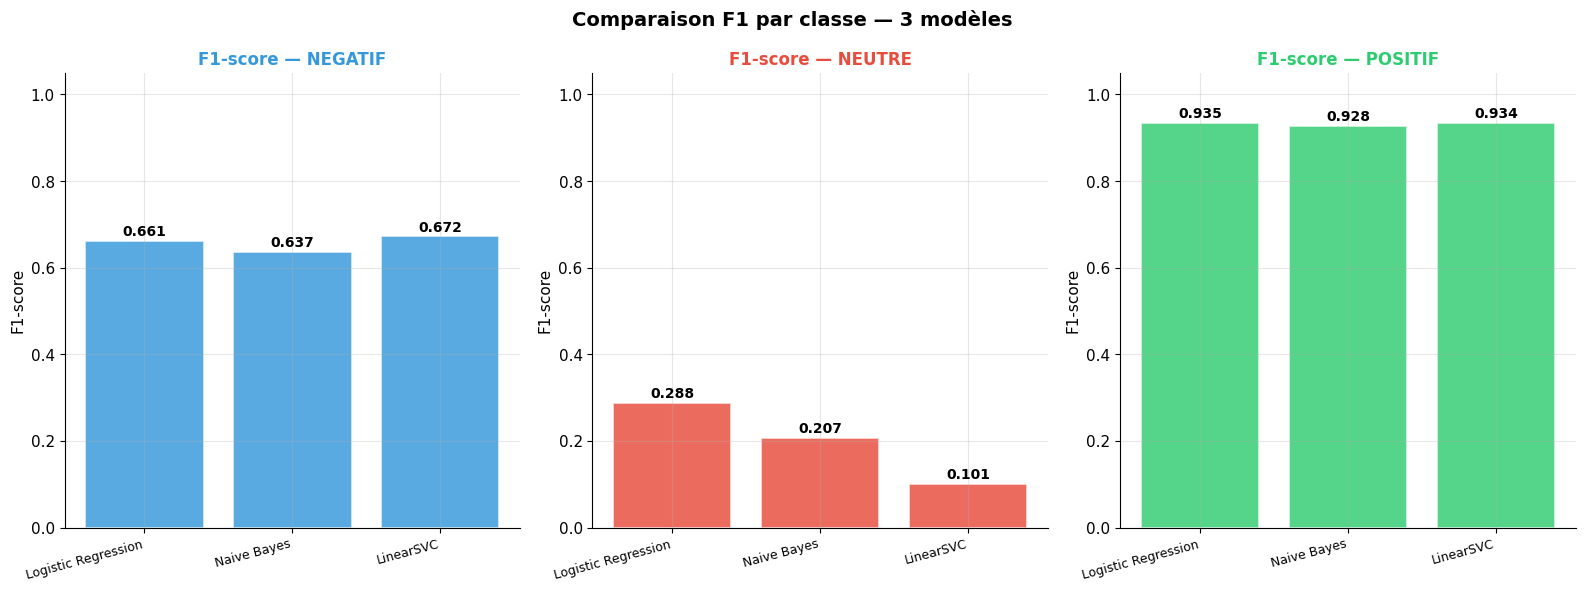

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
x_pos = np.arange(len(df_final))
bar_colors = ['#3498db', '#e74c3c', '#2ecc71']

for ax, classe, color in zip(axes, CLASSES, bar_colors):
    col = f'F1 {classe}'
    values = df_final[col].values
    bars = ax.bar(x_pos, values, color=color, alpha=0.82, edgecolor='white', linewidth=1.2)
    
    # Annotation des valeurs
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels([r['Modèle'].split('(')[0].strip() for _, r in df_final.iterrows()],
                       rotation=15, ha='right', fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_title(f'F1-score — {classe}', fontsize=12, fontweight='bold', color=color)
    ax.set_ylabel('F1-score')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Comparaison F1 par classe — 3 modèles', fontsize=14, fontweight='bold')
plt.tight_layout()
os.makedirs(os.path.join(REPO_PATH, 'visualisations'), exist_ok=True)
plt.savefig(os.path.join(REPO_PATH, 'visualisations', 'comparison_f1_par_classe.png'), dpi=150, bbox_inches='tight')
plt.show()

### 4 — Radar Chart : profil multidimensionnel des modèles

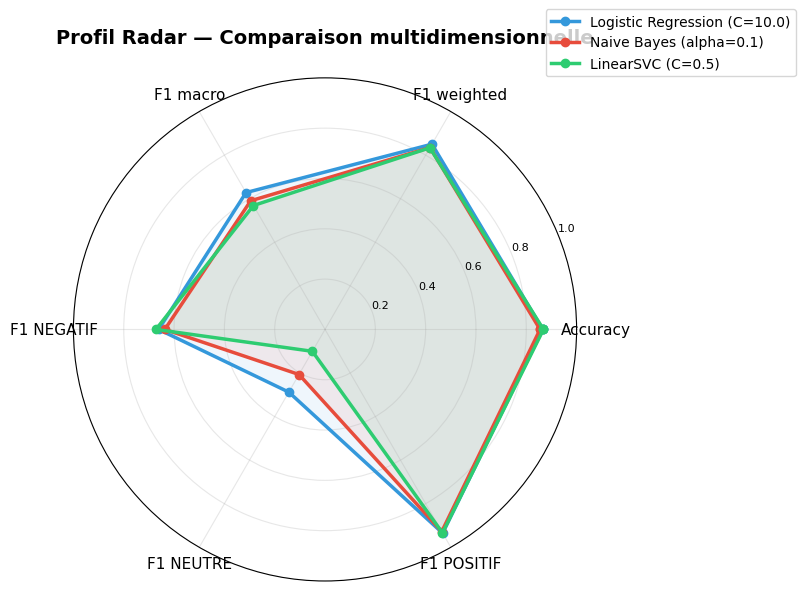

In [6]:
categories = ['Accuracy', 'F1 weighted', 'F1 macro', 'F1 NEGATIF', 'F1 NEUTRE', 'F1 POSITIF']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
colors = ['#3498db', '#e74c3c', '#2ecc71']
model_names = [r['Modèle'].split('(')[0].strip() for _, r in df_final.iterrows()]

for i, (_, row) in enumerate(df_final.iterrows()):
    values = [row[c] for c in categories]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2.5, color=colors[i],
            label=row['Modèle'], markersize=6)
    ax.fill(angles, values, alpha=0.08, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_title('Profil Radar — Comparaison multidimensionnelle', fontsize=14, fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.45, 1.15), fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(REPO_PATH, 'visualisations', 'comparison_radar_chart.png'), dpi=150, bbox_inches='tight')
plt.show()

### 5 — Matrices de confusion côte à côte

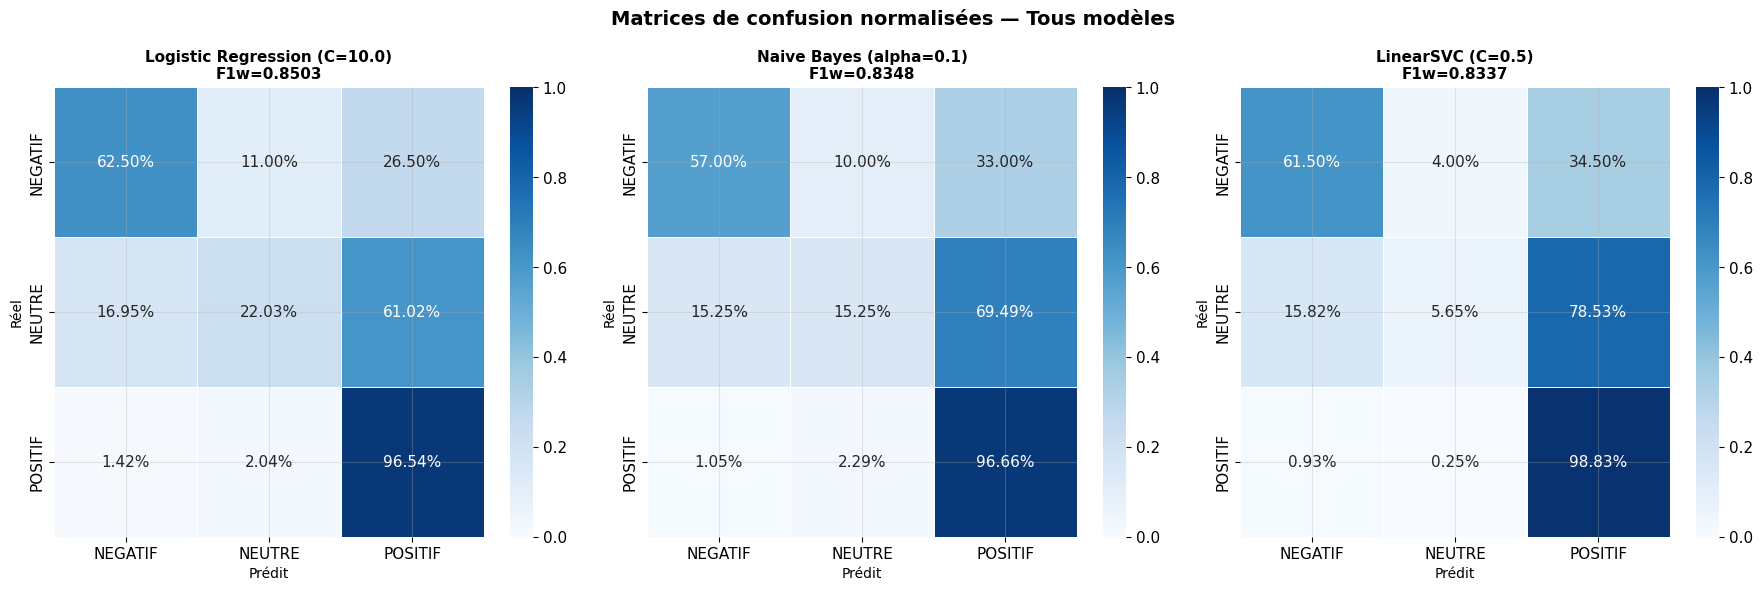

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (key, r) in zip(axes, tous.items()):
    cm = confusion_matrix(y_test, r['y_pred'], labels=CLASSES)
    cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES,
                ax=ax, linewidths=0.5, vmin=0, vmax=1,
                annot_kws={'size': 11})
    ax.set_title(f"{r['nom']}\nF1w={r['f1_weighted']:.4f}",
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Prédit', fontsize=10)
    ax.set_ylabel('Réel', fontsize=10)

plt.suptitle('Matrices de confusion normalisées — Tous modèles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPO_PATH, 'visualisations', 'comparison_confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

### 6 — Analyse spécifique : performance sur les classes déséquilibrées

In [8]:
# Analyse du déséquilibre : comment chaque modèle gère NEUTRE (177 exemples)
print("\n" + "="*65)
print("  ANALYSE DU DÉSÉQUILIBRE DE CLASSES")
print("="*65)
print(f"  Rappel : NEUTRE = {(y_test=='NEUTRE').sum()} exemples dans le test ({(y_test=='NEUTRE').mean()*100:.1f}%)")
print(f"           NEGATIF= {(y_test=='NEGATIF').sum()} exemples ({(y_test=='NEGATIF').mean()*100:.1f}%)")
print(f"           POSITIF= {(y_test=='POSITIF').sum()} exemples ({(y_test=='POSITIF').mean()*100:.1f}%)")

print("\n  F1-score NEUTRE par modèle :")
for _, row in df_final.iterrows():
    bar = '█' * int(row['F1 NEUTRE'] * 30)
    print(f"  {row['Modèle'][:30]:30} | {bar:<30} {row['F1 NEUTRE']:.4f}")

print("\n  F1-score NEGATIF par modèle (critique pour business) :")
for _, row in df_final.iterrows():
    bar = '█' * int(row['F1 NEGATIF'] * 30)
    print(f"  {row['Modèle'][:30]:30} | {bar:<30} {row['F1 NEGATIF']:.4f}")

print("\n💡 Insight : aucun modèle ne gère bien NEUTRE")
print("   → Piste d'amélioration : SMOTE (oversampling) ou class_weight='balanced'")
print("   → Pour le déploiement, NEUTRE sera parfois confondu avec POSITIF (acceptable)")


  ANALYSE DU DÉSÉQUILIBRE DE CLASSES
  Rappel : NEUTRE = 177 exemples dans le test (8.9%)
           NEGATIF= 200 exemples (10.0%)
           POSITIF= 1619 exemples (81.1%)

  F1-score NEUTRE par modèle :
  Logistic Regression (C=10.0)   | ████████                       0.2878
  Naive Bayes (alpha=0.1)        | ██████                         0.2069
  LinearSVC (C=0.5)              | ███                            0.1005

  F1-score NEGATIF par modèle (critique pour business) :
  Logistic Regression (C=10.0)   | ███████████████████            0.6614
  Naive Bayes (alpha=0.1)        | ███████████████████            0.6369
  LinearSVC (C=0.5)              | ████████████████████           0.6721

💡 Insight : aucun modèle ne gère bien NEUTRE
   → Piste d'amélioration : SMOTE (oversampling) ou class_weight='balanced'
   → Pour le déploiement, NEUTRE sera parfois confondu avec POSITIF (acceptable)


### 7 — Heatmap globale des métriques

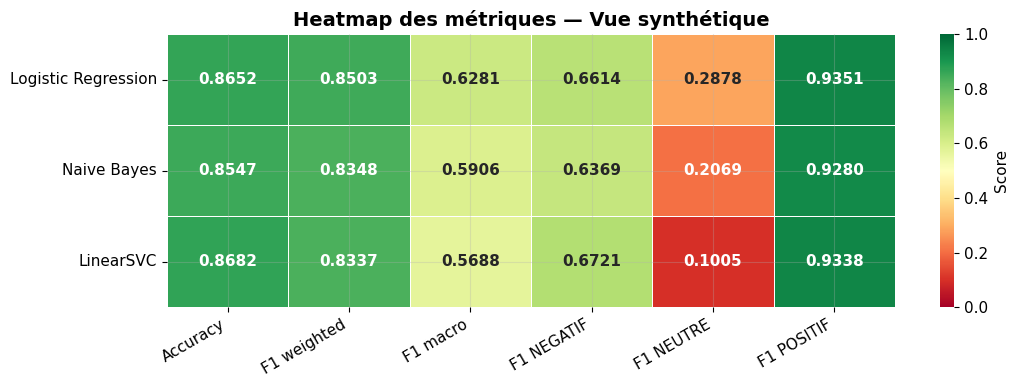

In [9]:
metric_cols = ['Accuracy', 'F1 weighted', 'F1 macro', 'F1 NEGATIF', 'F1 NEUTRE', 'F1 POSITIF']
heatmap_data = df_final.set_index('Modèle')[metric_cols]
short_names = [n.split('(')[0].strip() for n in heatmap_data.index]
heatmap_data.index = short_names

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='RdYlGn',
            vmin=0.0, vmax=1.0, ax=ax,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 11, 'weight': 'bold'},
            cbar_kws={'label': 'Score'})
ax.set_title('Heatmap des métriques — Vue synthétique', fontsize=14, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(REPO_PATH, 'visualisations', 'comparison_heatmap_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()

### 8 — Sélection du Champion & Justification

In [10]:
print("\n" + "🏆" * 20)
print("   SÉLECTION DU CHAMPION")
print("🏆" * 20)

champion_row  = df_final.iloc[0]
champion_key  = [k for k, v in tous.items() if v['nom'] == champion_row['Modèle']][0]
champion_data = tous[champion_key]
champion_model = champion_data['modele']

print(f"\n  Champion : {champion_row['Modèle']}")
print(f"  Rang     : 1er sur {len(df_final)} modèles")
print(f"\n  Métriques :")
print(f"    Accuracy    : {champion_row['Accuracy']:.4f}")
print(f"    F1 weighted : {champion_row['F1 weighted']:.4f}  ← critère de sélection")
print(f"    F1 macro    : {champion_row['F1 macro']:.4f}")
print(f"    F1 NEGATIF  : {champion_row['F1 NEGATIF']:.4f}  ← critique business")
print(f"    F1 NEUTRE   : {champion_row['F1 NEUTRE']:.4f}")
print(f"    F1 POSITIF  : {champion_row['F1 POSITIF']:.4f}")

print(f"\n  Justification du choix (F1 weighted comme critère principal) :")
print(f"    1. F1 weighted tient compte du déséquilibre de classes")
print(f"       (évite de favoriser artificiellement POSITIF qui domine à 81%)")
print(f"    2. F1 NEGATIF = {champion_row['F1 NEGATIF']:.4f} — meilleur ou compétitif sur les avis critiques")
print(f"    3. Support probabiliste → confiance exportable via l'API FastAPI")
print(f"    4. Interprétable → les coefficients explicables pour les stakeholders")

# Marges par rapport aux autres modèles
print(f"\n  Avantage sur les autres modèles :")
for i, (_, row) in enumerate(df_final.iterrows()):
    if i > 0:
        diff = champion_row['F1 weighted'] - row['F1 weighted']
        print(f"    vs {row['Modèle'][:30]:30} : +{diff:.4f} en F1 weighted")


🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆
   SÉLECTION DU CHAMPION
🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆

  Champion : Logistic Regression (C=10.0)
  Rang     : 1er sur 3 modèles

  Métriques :
    Accuracy    : 0.8652
    F1 weighted : 0.8503  ← critère de sélection
    F1 macro    : 0.6281
    F1 NEGATIF  : 0.6614  ← critique business
    F1 NEUTRE   : 0.2878
    F1 POSITIF  : 0.9351

  Justification du choix (F1 weighted comme critère principal) :
    1. F1 weighted tient compte du déséquilibre de classes
       (évite de favoriser artificiellement POSITIF qui domine à 81%)
    2. F1 NEGATIF = 0.6614 — meilleur ou compétitif sur les avis critiques
    3. Support probabiliste → confiance exportable via l'API FastAPI
    4. Interprétable → les coefficients explicables pour les stakeholders

  Avantage sur les autres modèles :
    vs Naive Bayes (alpha=0.1)        : +0.0155 en F1 weighted
    vs LinearSVC (C=0.5)              : +0.0166 en F1 weighted


### 9 — Sauvegarde du champion

In [11]:
joblib.dump(champion_model, os.path.join(models_path, 'best_model_champion.pkl'))
joblib.dump(df_final,        os.path.join(models_path, 'comparison_results.pkl'))

print("✅ Sauvegardé :")
print(f"   → models/best_model_champion.pkl  ({champion_row['Modèle']})")
print("   → models/comparison_results.pkl")
print()
print("   Visualisations générées :")
for viz in ['comparison_f1_par_classe.png', 'comparison_radar_chart.png',
            'comparison_confusion_matrices.png', 'comparison_heatmap_metrics.png']:
    path = os.path.join(REPO_PATH, 'visualisations', viz)
    if os.path.exists(path):
        print(f"   ✅ visualisations/{viz}")
    else:
        print(f"   ⚠️  visualisations/{viz}  (non trouvé)")

print()
print("🚀 Le champion est prêt pour le déploiement dans app/main.py")

✅ Sauvegardé :
   → models/best_model_champion.pkl  (Logistic Regression (C=10.0))
   → models/comparison_results.pkl

   Visualisations générées :
   ✅ visualisations/comparison_f1_par_classe.png
   ✅ visualisations/comparison_radar_chart.png
   ✅ visualisations/comparison_confusion_matrices.png
   ✅ visualisations/comparison_heatmap_metrics.png

🚀 Le champion est prêt pour le déploiement dans app/main.py
